### Dependencies

In [29]:
%pip install scikit-learn
%pip install numpy
%pip install matplotlib
%pip install pyod
%pip install torch
%pip install combo
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
from sklearn.datasets import make_blobs
import numpy as np
from sklearn.preprocessing import Normalizer
import matplotlib.pyplot as plt
from pyod.models.iforest import IForest
from pyod.models.dif import DIF
from pyod.models.loda import LODA
from mpl_toolkits.mplot3d import Axes3D
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import roc_auc_score

### Exercise 1

In [3]:
def ex1_1():
    num_samples = 500
    miu = [0.0, 0.0]
    sigma = [1.0, 1.0]
    
    dataset = make_blobs(n_samples=num_samples,
        centers=[miu], cluster_std=[sigma],
        n_features=2, random_state=23)

    return dataset


dataset_ex1_1 = ex1_1()
X_ex1 = dataset_ex1_1[0]
Y_ex1 = dataset_ex1_1[1]
print(f'X Shape: {X_ex1.shape}')
print(f'Y Shape: {Y_ex1.shape}')

X Shape: (500, 2)
Y Shape: (500,)


projection_vectors norms: [1. 1. 1. 1. 1.]


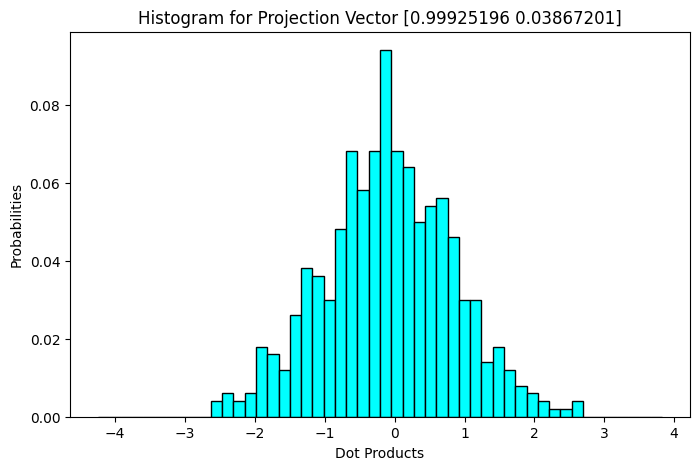

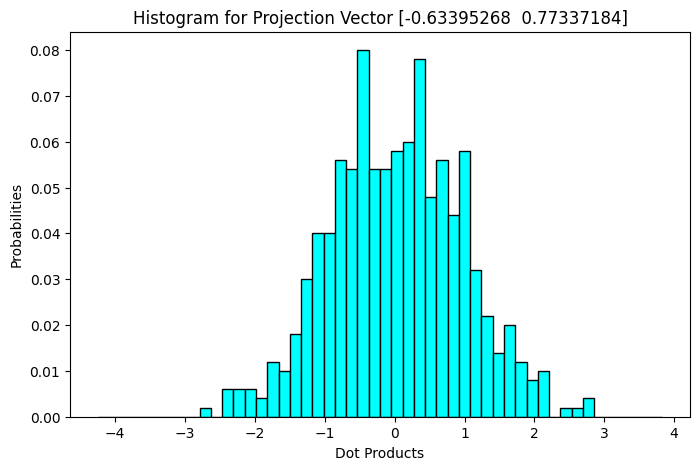

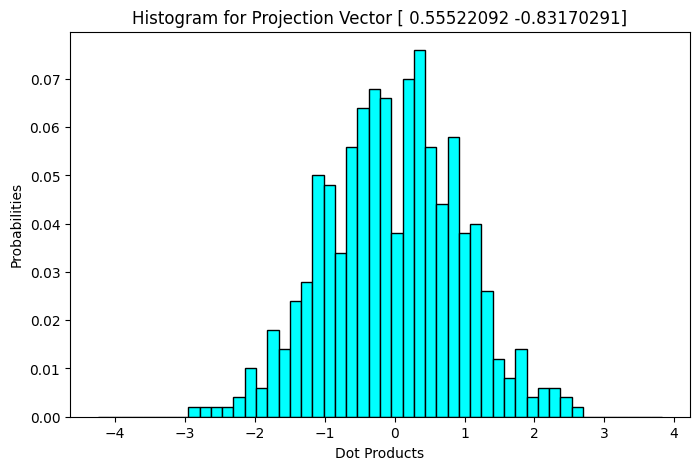

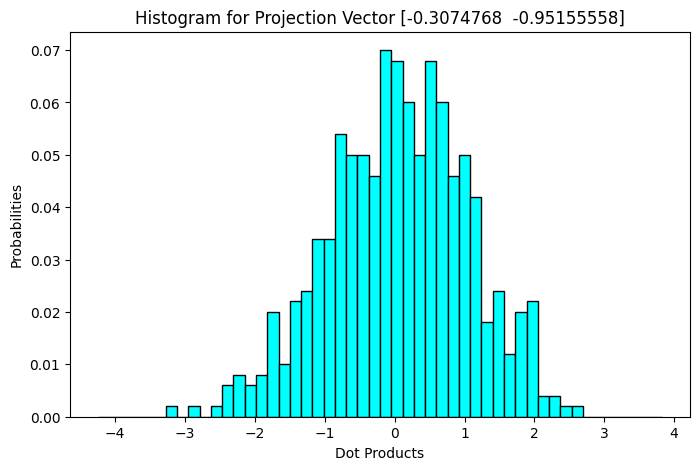

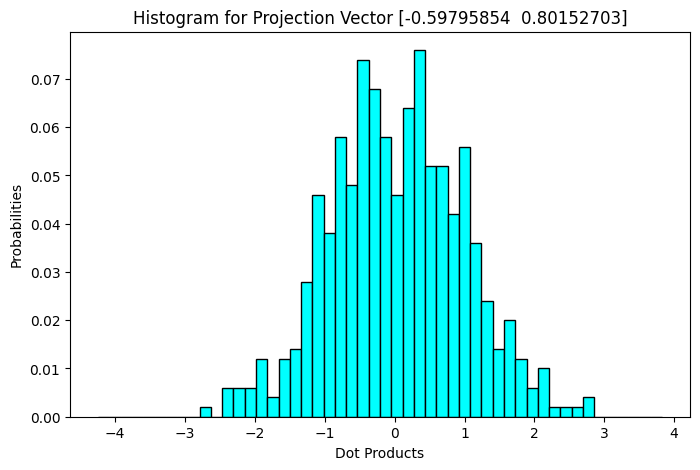

In [4]:
def ex1_2(X, num_bins, plot):
    num_projection_vectors = 5

    mean = [0.0, 0.0]
    covariance = [[1.0, 0.0], [0.0, 1.0]]

    np.random.seed(23)
    projection_vectors = np.random.multivariate_normal(mean=mean, 
        cov=covariance, size=num_projection_vectors)

    normalizer = Normalizer(norm='l2')
    normalizer.fit(projection_vectors)
    projection_vectors = normalizer.transform(projection_vectors)

    print(f'projection_vectors norms: {np.linalg.norm(projection_vectors, ord=2, axis=1)}')

    X_projections = np.dot(X, projection_vectors.T)

    proj_min = np.min(X_projections)
    proj_max = np.max(X_projections)

    delta = 1.0
    val_range = (proj_min - delta, proj_max + delta)

    probs_per_proj = np.zeros((X.shape[0], num_projection_vectors))

    for proj_idx, proj_vect in enumerate(projection_vectors):
        X_proj = X_projections[:, proj_idx]

        counts, edges = np.histogram(X_proj, bins=num_bins, range=val_range)
        probabilities = counts.astype(float) / np.sum(counts)

        bin_centers = (edges[:-1] + edges[1:]) / 2.0
        bin_width = edges[1] - edges[0]

        if plot:
            plt.figure(figsize=(8, 5))
            plt.bar(bin_centers, probabilities, width=bin_width,
                color='cyan', edgecolor='black')
            plt.title(f'Histogram for Projection Vector {proj_vect}')
            plt.xlabel('Dot Products')
            plt.ylabel('Probabilities')
            plt.show()

        bin_indices = np.digitize(X_proj, edges) - 1  # np.digitize() e 1-indexed
        bin_indices = np.clip(bin_indices, 0, num_bins - 1)
        probs_per_proj[:, proj_idx] = probabilities[bin_indices]

    normality_scores = np.mean(probs_per_proj, axis=1)
    epsilon = 1e-8
    anomaly_scores = -np.log(normality_scores + epsilon)

    return anomaly_scores


anomaly_scores_ex1_2 = ex1_2(X_ex1, num_bins=50, plot=True)

projection_vectors norms: [1. 1. 1. 1. 1.]


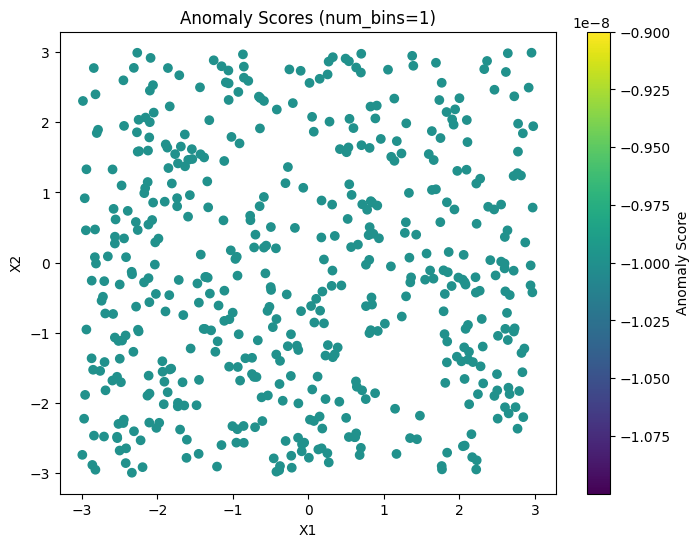

projection_vectors norms: [1. 1. 1. 1. 1.]


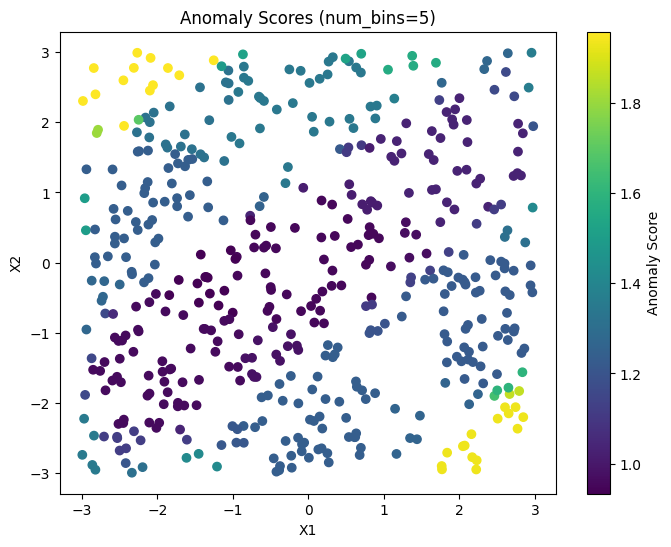

projection_vectors norms: [1. 1. 1. 1. 1.]


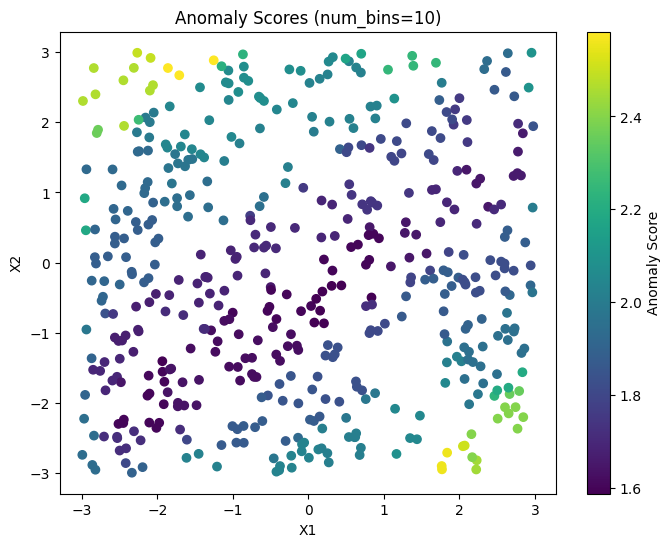

projection_vectors norms: [1. 1. 1. 1. 1.]


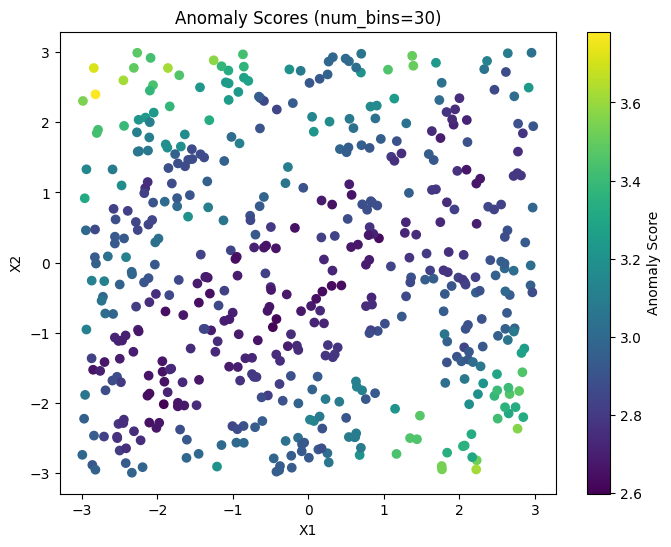

projection_vectors norms: [1. 1. 1. 1. 1.]


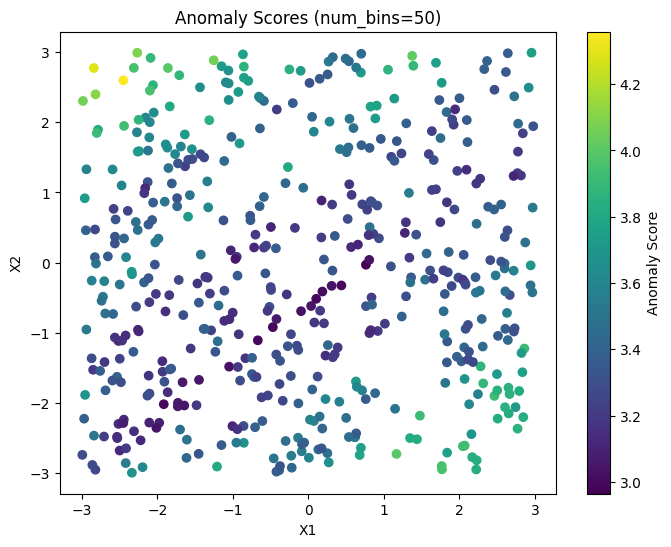

projection_vectors norms: [1. 1. 1. 1. 1.]


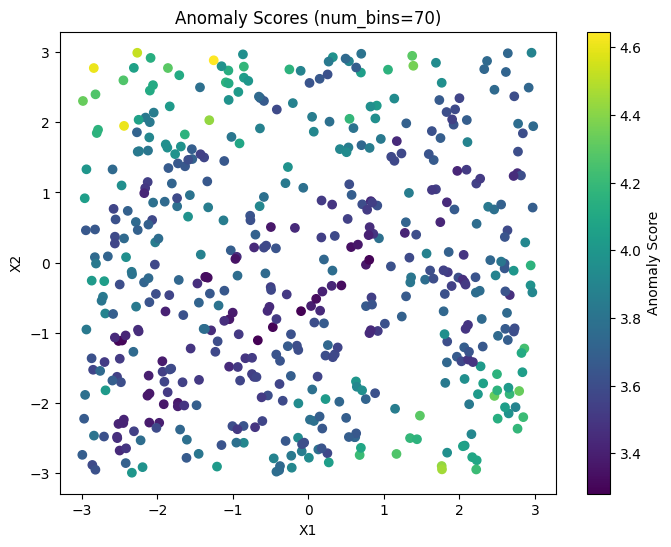

projection_vectors norms: [1. 1. 1. 1. 1.]


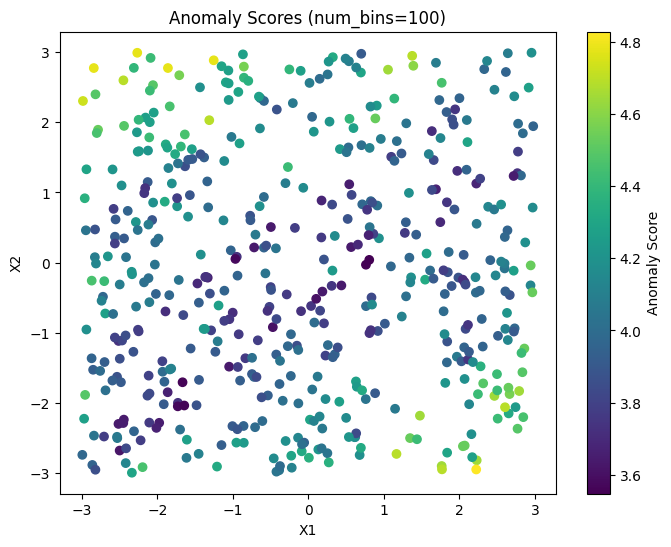

In [5]:
def ex1_3():
    num_samples = 500
    low = -3.0
    high = 3.0

    X = np.random.uniform(low=low, high=high, size=(num_samples, 2))

    nums_bins = [1, 5, 10, 30, 50, 70, 100]
    for num_bins in nums_bins:
        anomaly_scores = ex1_2(X, num_bins=num_bins, plot=False)

        plt.figure(figsize=(8, 6))
        plt.scatter(X[:, 0], X[:, 1], c=anomaly_scores)
        plt.colorbar(label='Anomaly Score')
        plt.title(f'Anomaly Scores (num_bins={num_bins})')
        plt.xlabel('X1')
        plt.ylabel('X2')
        plt.show()


ex1_3()

### Conclusion:
The anomaly scores go up as we increase the number of bins.

### Exercise 2

Dataset Shape: (500, 2)


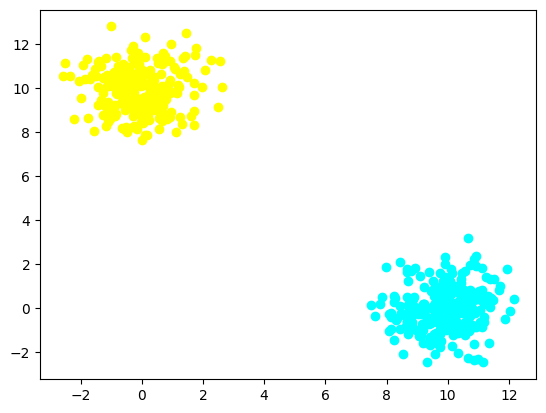

In [23]:
def ex2_1():
    num_samples = 500
    mius = [[10.0, 0.0], [0.0, 10.0]]
    sigmas = [[1.0, 1.0], [1.0, 1.0]]

    dataset = make_blobs(n_samples=num_samples,
        centers=mius, cluster_std=sigmas,
        n_features=2, random_state=23, shuffle=True)

    X = dataset[0]
    Y = dataset[1]

    plt.scatter(X[Y == 0][:, 0], X[Y == 0][:, 1], c='cyan')
    plt.scatter(X[Y == 1][:, 0], X[Y == 1][:, 1], c='yellow')

    return dataset


dataset_ex2_1 = ex2_1()
X_ex2_1 = dataset_ex2_1[0]
Y_ex2_1 = dataset_ex2_1[1]
print(f'Dataset Shape: {X_ex2_1.shape}')

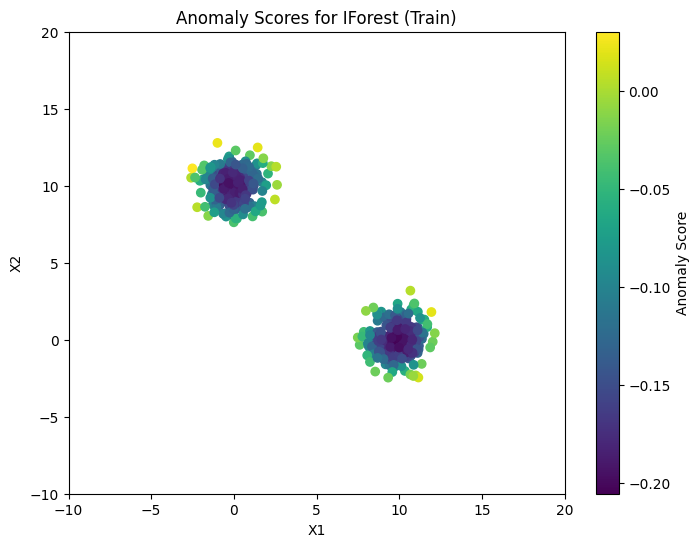

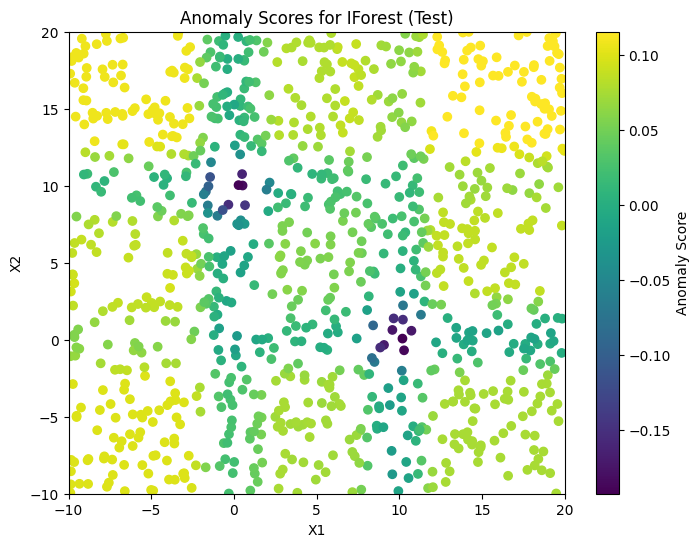

In [24]:
def ex2_2(X_train):
    num_samples = 1000
    low = -10.0
    high = 20.0

    X_test = np.random.uniform(low=low, high=high, size=(num_samples, 2))

    i_forest = IForest(contamination=0.02, random_state=23)
    i_forest.fit(X_train)

    anomaly_scores_train = i_forest.decision_function(X_train)
    anomaly_scores_test = i_forest.decision_function(X_test)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_train[:, 0], X_train[:, 1], c=anomaly_scores_train)
    plt.colorbar(label='Anomaly Score')
    plt.title(f'Anomaly Scores for IForest (Train)')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.xlim(low, high)
    plt.ylim(low, high)
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.scatter(X_test[:, 0], X_test[:, 1], c=anomaly_scores_test)
    plt.colorbar(label='Anomaly Score')
    plt.title(f'Anomaly Scores for IForest (Test)')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.xlim(low, high)
    plt.ylim(low, high)
    plt.show()


ex2_2(X_ex2_1)

We can see that, since the threshold lines of the isolation forest are axis-aligned, they become easily visible in the anomaly score map.

c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't

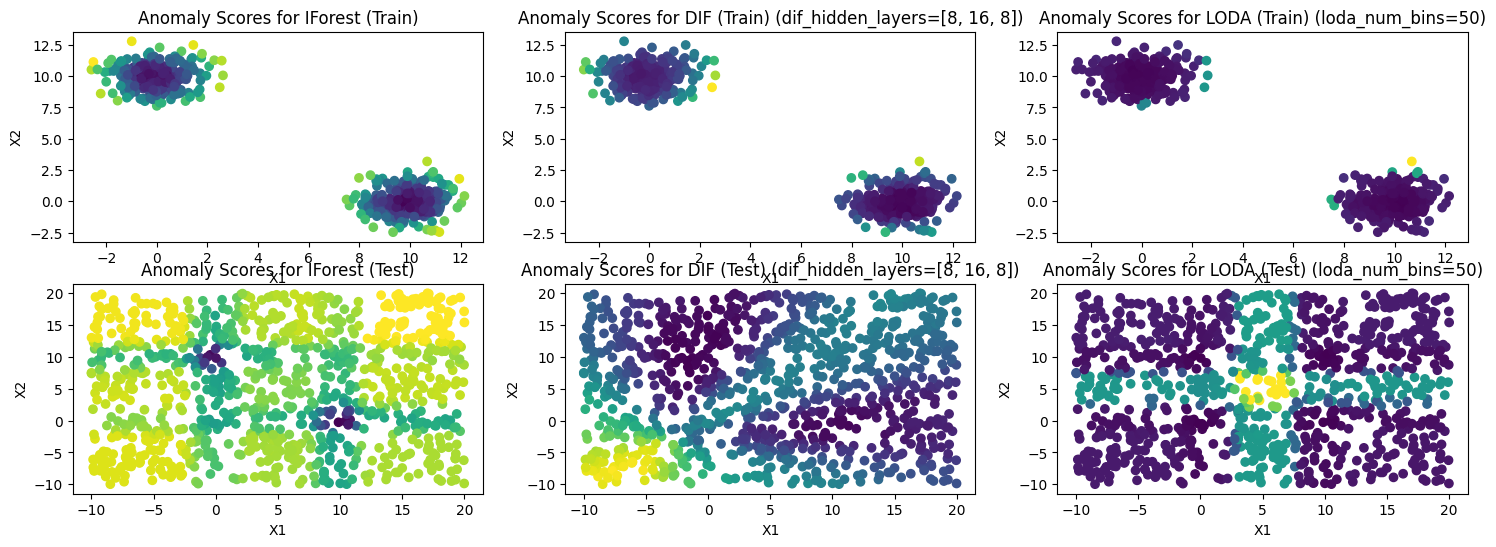

c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't

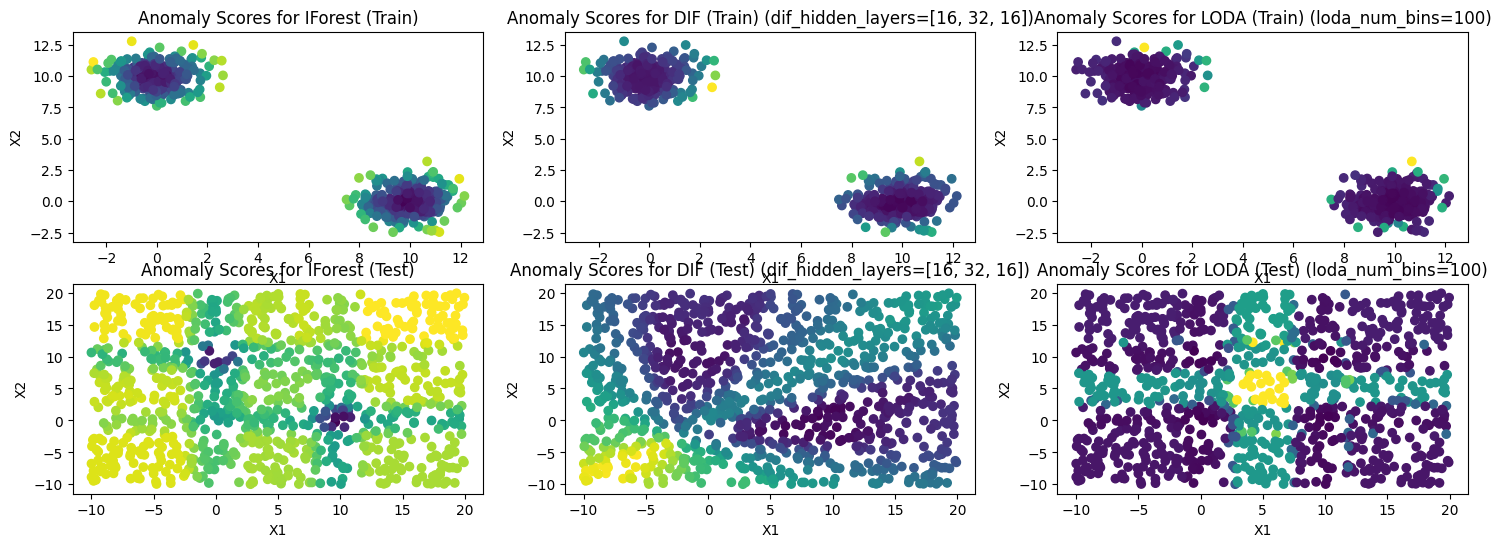

c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't

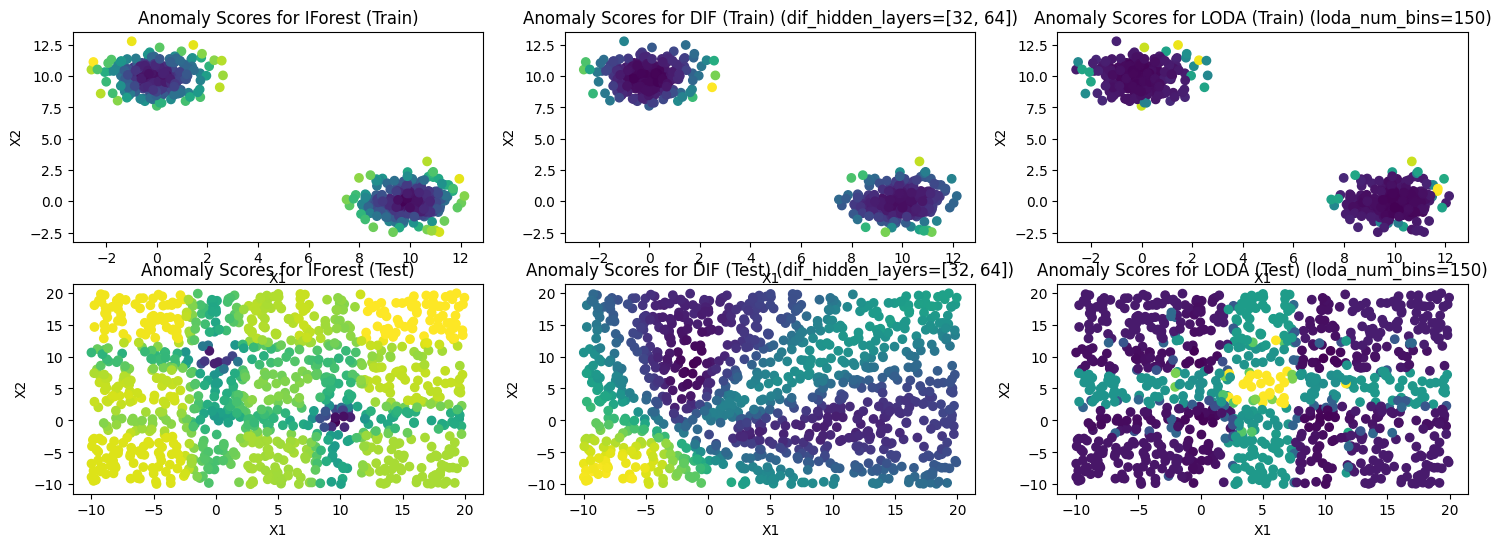

c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't

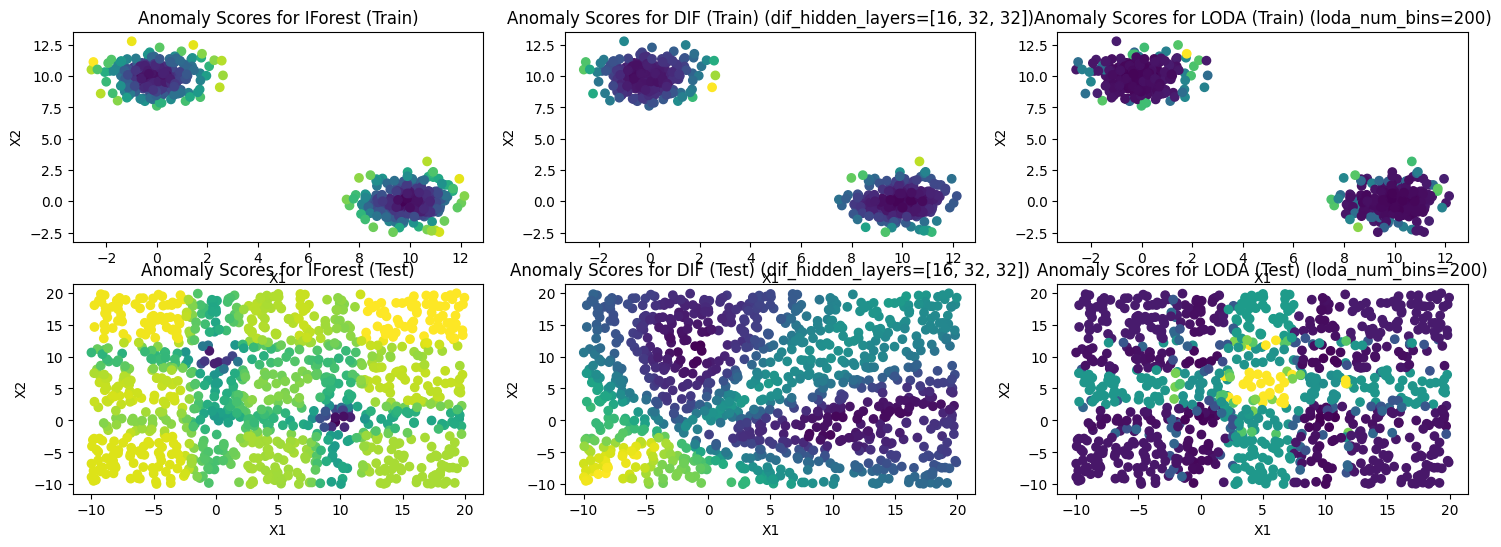

In [25]:
def ex2_4(X_train, dif_hidden_layers, loda_num_bins):
    num_samples = 1000
    low = -10.0
    high = 20.0

    X_test = np.random.uniform(low=low, high=high, size=(num_samples, 2))

    i_forest = IForest(contamination=0.02, random_state=23)
    i_forest.fit(X_train)

    anomaly_scores_train_i_forest = i_forest.decision_function(X_train)
    anomaly_scores_test_i_forest = i_forest.decision_function(X_test)

    dif = DIF(contamination=0.02, hidden_neurons=dif_hidden_layers, random_state=23)
    dif.fit(X_train)

    anomaly_scores_train_dif = dif.decision_function(X_train)
    anomaly_scores_test_dif = dif.decision_function(X_test)

    loda = LODA(contamination=0.02, n_bins=loda_num_bins)
    loda.fit(X_train)

    anomaly_scores_train_loda = loda.decision_function(X_train)
    anomaly_scores_test_loda = loda.decision_function(X_test)

    _, axes = plt.subplots(2, 3, figsize=(18, 6))
    axes = axes.flatten()

    axes[0].scatter(X_train[:, 0], X_train[:, 1], c=anomaly_scores_train_i_forest)
    axes[0].set_title(f'Anomaly Scores for IForest (Train)')
    axes[0].set_xlabel('X1')
    axes[0].set_ylabel('X2')
    # axes[0].legend()

    axes[3].scatter(X_test[:, 0], X_test[:, 1], c=anomaly_scores_test_i_forest)
    axes[3].set_title(f'Anomaly Scores for IForest (Test)')
    axes[3].set_xlabel('X1')
    axes[3].set_ylabel('X2')
    # axes[3].legend()

    axes[1].scatter(X_train[:, 0], X_train[:, 1], c=anomaly_scores_train_dif)
    axes[1].set_title(f'Anomaly Scores for DIF (Train) (dif_hidden_layers={dif_hidden_layers})')
    axes[1].set_xlabel('X1')
    axes[1].set_ylabel('X2')
    # axes[1].legend()

    axes[4].scatter(X_test[:, 0], X_test[:, 1], c=anomaly_scores_test_dif)
    axes[4].set_title(f'Anomaly Scores for DIF (Test) (dif_hidden_layers={dif_hidden_layers})')
    axes[4].set_xlabel('X1')
    axes[4].set_ylabel('X2')
    # axes[4].legend()

    axes[2].scatter(X_train[:, 0], X_train[:, 1], c=anomaly_scores_train_loda)
    axes[2].set_title(f'Anomaly Scores for LODA (Train) (loda_num_bins={loda_num_bins})')
    axes[2].set_xlabel('X1')
    axes[2].set_ylabel('X2')
    # axes[2].legend()

    axes[5].scatter(X_test[:, 0], X_test[:, 1], c=anomaly_scores_test_loda)
    axes[5].set_title(f'Anomaly Scores for LODA (Test) (loda_num_bins={loda_num_bins})')
    axes[5].set_xlabel('X1')
    axes[5].set_ylabel('X2')
    # axes[5].legend()

    plt.show()


ex2_4(X_train=X_ex2_1, dif_hidden_layers=[8, 16, 8], loda_num_bins=50)
ex2_4(X_train=X_ex2_1, dif_hidden_layers=[16, 32, 16], loda_num_bins=100)
ex2_4(X_train=X_ex2_1, dif_hidden_layers=[32, 64], loda_num_bins=150)
ex2_4(X_train=X_ex2_1, dif_hidden_layers=[16, 32, 32], loda_num_bins=200)

Dataset Shape: (500, 3)


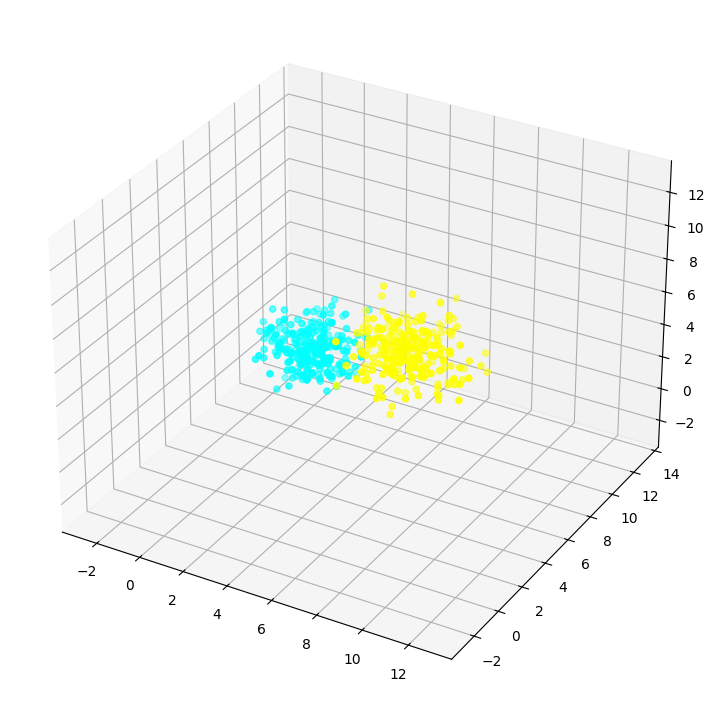

In [35]:
def ex2_6_1():
    num_samples = 500
    mius = [[0.0, 10.0, 0.0], [10.0, 0.0, 10.0]]
    sigmas = [[1.0, 1.0, 1.0], [1.0, 1.0, 1.0]]

    dataset = make_blobs(n_samples=num_samples,
        centers=mius, cluster_std=sigmas,
        n_features=3, random_state=23, shuffle=True)

    X = dataset[0]
    Y = dataset[1]

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X[Y == 0][:, 0], X[Y == 0][:, 1], X[Y == 0][:, 2], c='cyan')
    ax.scatter(X[Y == 1][:, 0], X[Y == 1][:, 1], X[Y == 1][:, 2], c='yellow')

    return dataset


dataset_ex2_6_1 = ex2_6_1()
X_ex2_6_1 = dataset_ex2_6_1[0]
Y_ex2_6_1 = dataset_ex2_6_1[1]
print(f'Dataset Shape: {X_ex2_6_1.shape}')

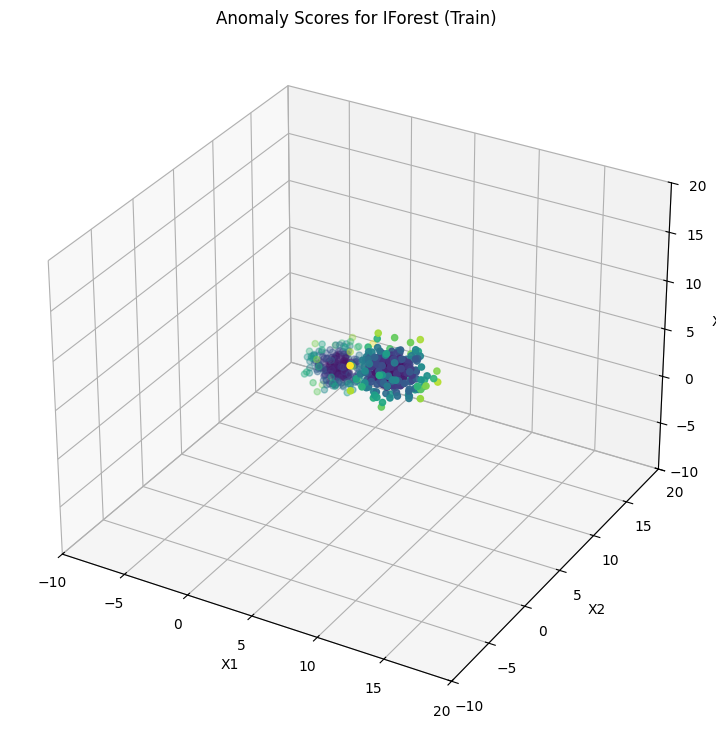

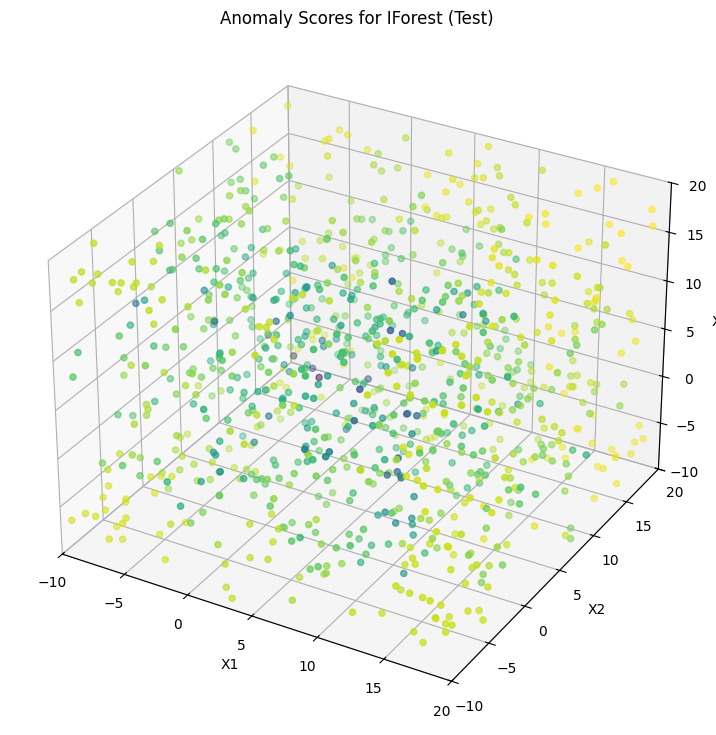

In [39]:
def ex2_6_2(X_train):
    num_samples = 1000
    low = -10.0
    high = 20.0

    X_test = np.random.uniform(low=low, high=high, size=(num_samples, 3))

    i_forest = IForest(contamination=0.02, random_state=23)
    i_forest.fit(X_train)

    anomaly_scores_train = i_forest.decision_function(X_train)
    anomaly_scores_test = i_forest.decision_function(X_test)

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=anomaly_scores_train)
    ax.set_title(f'Anomaly Scores for IForest (Train)')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)
    ax.set_zlim(low, high)
    plt.show()

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=anomaly_scores_test)
    ax.set_title(f'Anomaly Scores for IForest (Test)')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)
    ax.set_zlim(low, high)
    plt.show()


ex2_6_2(X_ex2_6_1)

c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't

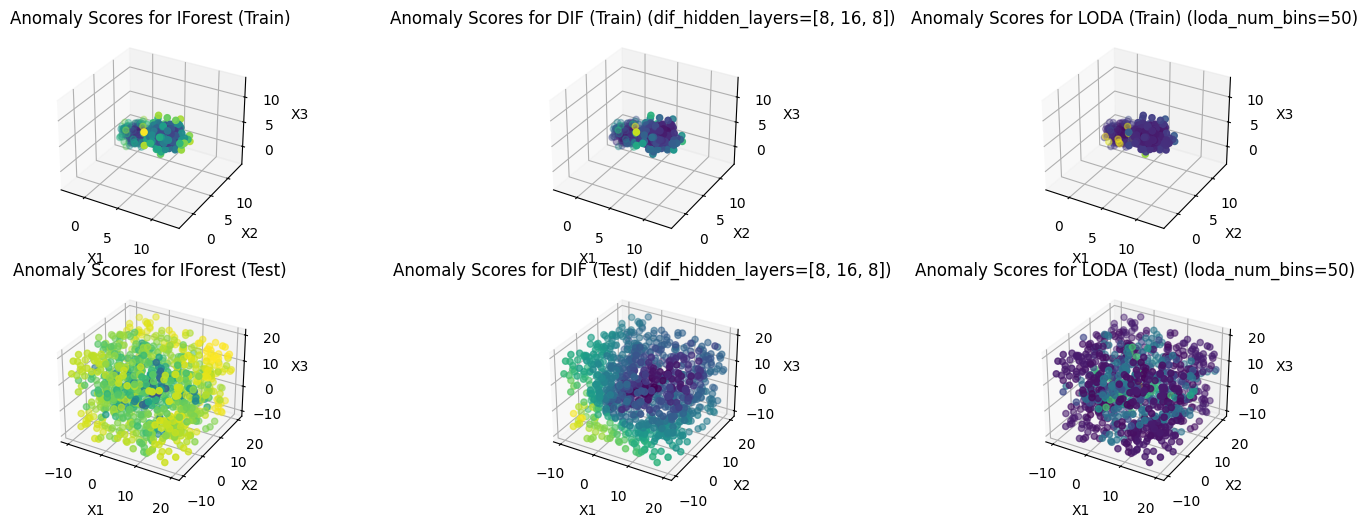

c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't

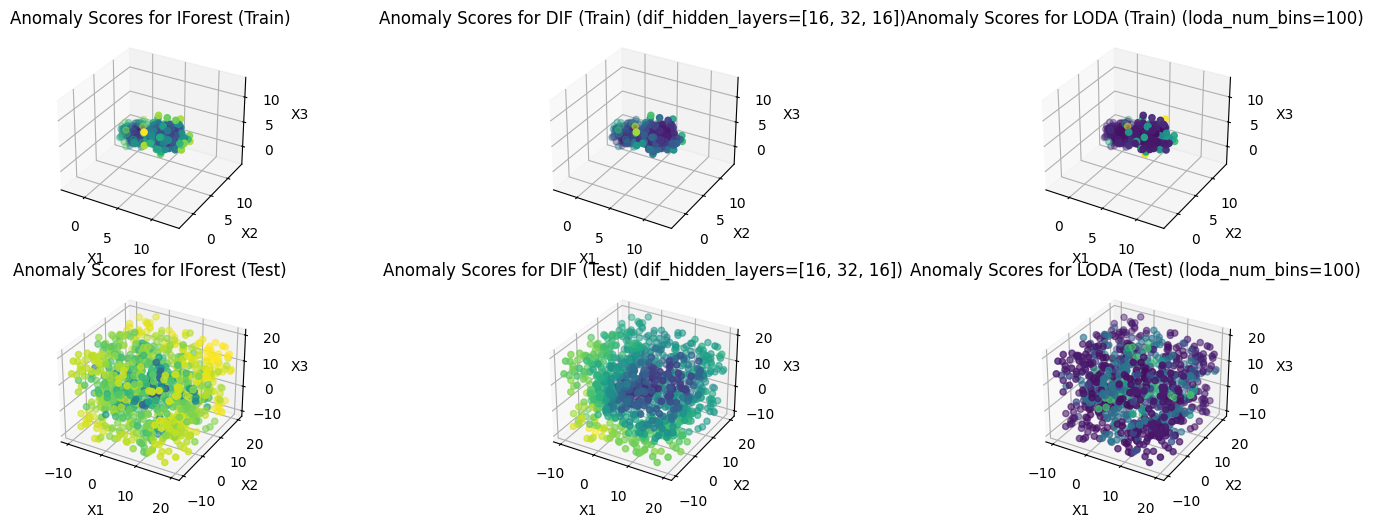

c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't

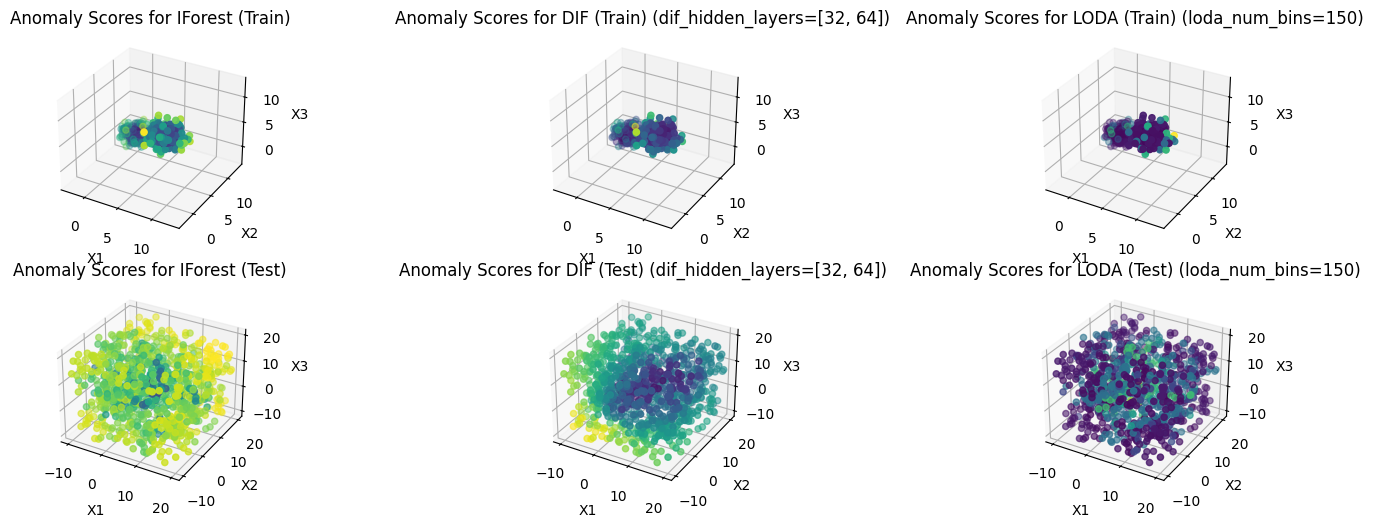

c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't

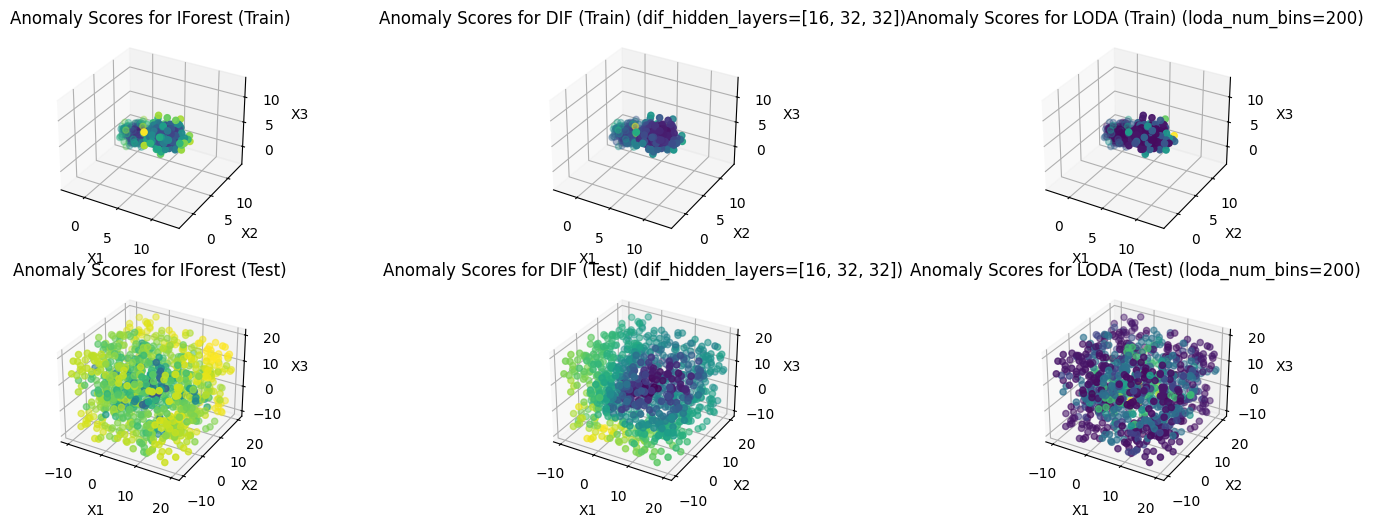

In [ ]:
def ex2_6_4(X_train, dif_hidden_layers, loda_num_bins):
    num_samples = 1000
    low = -10.0
    high = 20.0

    X_test = np.random.uniform(low=low, high=high, size=(num_samples, 3))

    i_forest = IForest(contamination=0.02, random_state=23)
    i_forest.fit(X_train)

    anomaly_scores_train_i_forest = i_forest.decision_function(X_train)
    anomaly_scores_test_i_forest = i_forest.decision_function(X_test)

    dif = DIF(contamination=0.02, hidden_neurons=dif_hidden_layers, random_state=23)
    dif.fit(X_train)

    anomaly_scores_train_dif = dif.decision_function(X_train)
    anomaly_scores_test_dif = dif.decision_function(X_test)

    loda = LODA(contamination=0.02, n_bins=loda_num_bins)
    loda.fit(X_train)

    anomaly_scores_train_loda = loda.decision_function(X_train)
    anomaly_scores_test_loda = loda.decision_function(X_test)

    _, axes = plt.subplots(2, 3, figsize=(18, 6), subplot_kw={'projection': '3d'})
    axes = axes.flatten()

    axes[0].scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=anomaly_scores_train_i_forest)
    axes[0].set_title(f'Anomaly Scores for IForest (Train)')
    axes[0].set_xlabel('X1')
    axes[0].set_ylabel('X2')
    axes[0].set_zlabel('X3')
    # axes[0].legend()

    axes[3].scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=anomaly_scores_test_i_forest)
    axes[3].set_title(f'Anomaly Scores for IForest (Test)')
    axes[3].set_xlabel('X1')
    axes[3].set_ylabel('X2')
    axes[3].set_zlabel('X3')
    # axes[3].legend()

    axes[1].scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2],c=anomaly_scores_train_dif)
    axes[1].set_title(f'Anomaly Scores for DIF (Train) (dif_hidden_layers={dif_hidden_layers})')
    axes[1].set_xlabel('X1')
    axes[1].set_ylabel('X2')
    axes[1].set_zlabel('X3')
    # axes[1].legend()

    axes[4].scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=anomaly_scores_test_dif)
    axes[4].set_title(f'Anomaly Scores for DIF (Test) (dif_hidden_layers={dif_hidden_layers})')
    axes[4].set_xlabel('X1')
    axes[4].set_ylabel('X2')
    axes[4].set_zlabel('X3')
    # axes[4].legend()

    axes[2].scatter(X_train[:, 0], X_train[:, 1], X_train[:, 2], c=anomaly_scores_train_loda)
    axes[2].set_title(f'Anomaly Scores for LODA (Train) (loda_num_bins={loda_num_bins})')
    axes[2].set_xlabel('X1')
    axes[2].set_ylabel('X2')
    axes[2].set_zlabel('X3')
    # axes[2].legend()

    axes[5].scatter(X_test[:, 0], X_test[:, 1], X_test[:, 2], c=anomaly_scores_test_loda)
    axes[5].set_title(f'Anomaly Scores for LODA (Test) (loda_num_bins={loda_num_bins})')
    axes[5].set_xlabel('X1')
    axes[5].set_ylabel('X2')
    axes[5].set_zlabel('X3')
    # axes[5].legend()

    plt.show()


ex2_6_4(X_train=X_ex2_6_1, dif_hidden_layers=[8, 16, 8], loda_num_bins=50)
ex2_6_4(X_train=X_ex2_6_1, dif_hidden_layers=[16, 32, 16], loda_num_bins=100)
ex2_6_4(X_train=X_ex2_6_1, dif_hidden_layers=[32, 64], loda_num_bins=150)
ex2_6_4(X_train=X_ex2_6_1, dif_hidden_layers=[16, 32, 32], loda_num_bins=200)

### Exercise 3

In [53]:
def ex3_1(X, Y, test_percentage):
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_percentage, shuffle=True, random_state=23)
    
    standard_scaler = StandardScaler()
    standard_scaler.fit(X_train)
    X_train = standard_scaler.transform(X_train)
    X_test = standard_scaler.transform(X_test)

    return X_train, Y_train, X_test, Y_test


shuttle_mat = loadmat('shuttle.mat')
X_shuttle_mat = shuttle_mat['X']
Y_shuttle_mat = shuttle_mat['y']

X_train_ex3_1, Y_train_ex3_1, X_test_ex3_1, Y_test_ex3_1 = ex3_1(X=X_shuttle_mat, Y=Y_shuttle_mat, test_percentage=0.4)
print(f'Train X Shape: {X_train_ex3_1.shape}')
print(f'Test X Shape: {X_test_ex3_1.shape}')
print(f'Train Y Shape: {Y_train_ex3_1.shape}')
print(f'Test Y Shape: {Y_test_ex3_1.shape}')

Train X Shape: (29458, 9)
Test X Shape: (19639, 9)
Train Y Shape: (29458, 1)
Test Y Shape: (19639, 1)


c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
c:\Master\Homework-Anomaly-Detection-AD\Laboratories\.venv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't

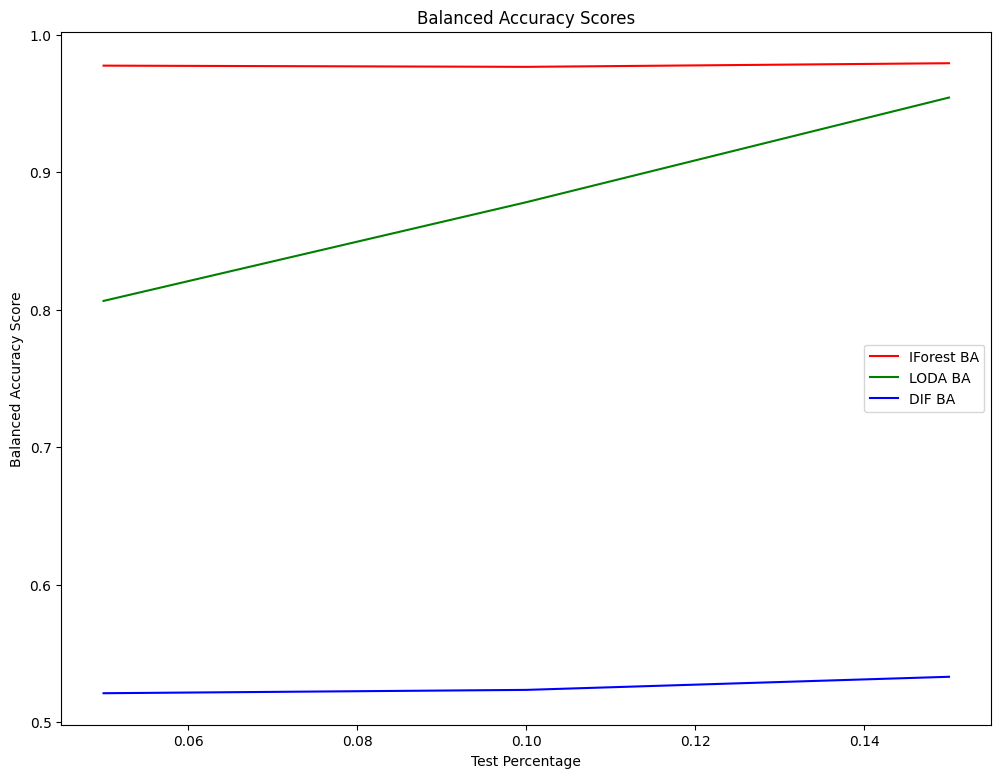

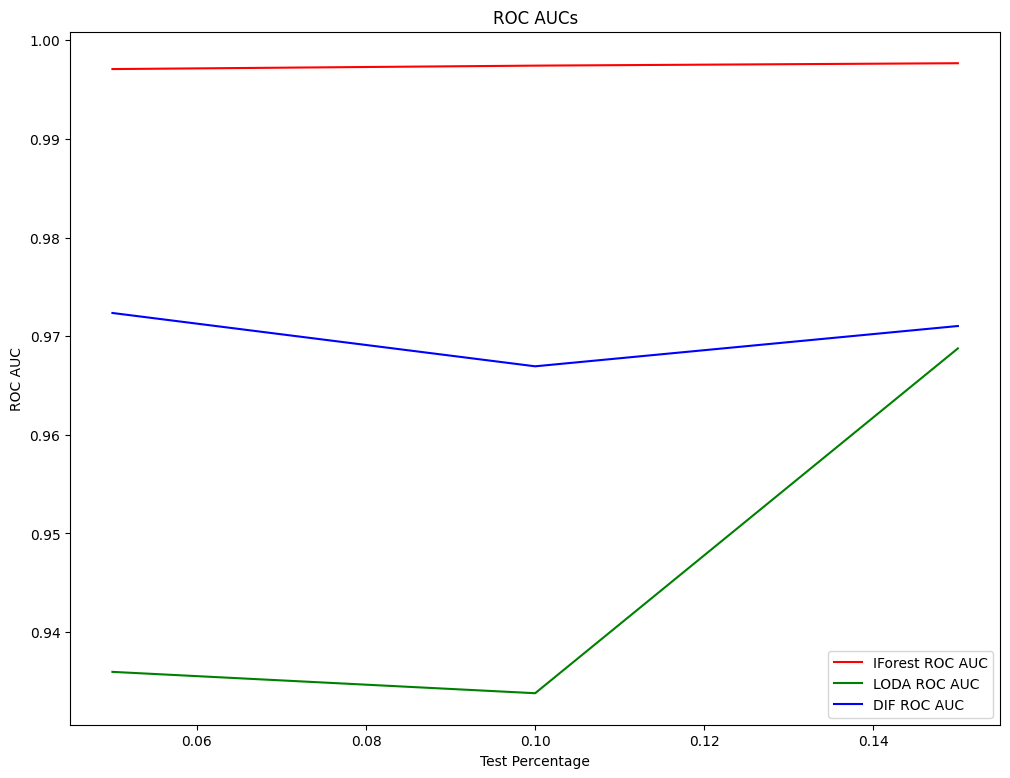

IForest: Mean Balanced Accuracy: 0.9778085810877427, Mean ROC AUC: 0.9974000930707682
LODA: Mean Balanced Accuracy: 0.8796284813449483, Mean ROC AUC: 0.9461807528732337
DIF: Mean Balanced Accuracy: 0.5258492980423438, Mean ROC AUC: 0.9701145608266547


In [61]:
def ex3_2(X, Y):
    test_percentages = [0.05 * i for i in range(1, 4)]

    bas_i_forest = []
    roc_aucs_i_forest = []
    bas_loda = []
    roc_aucs_loda = []
    bas_dif = []
    roc_aucs_dif = []
    for test_percentage in test_percentages:
        X_train, Y_train, X_test, Y_test = ex3_1(X=X, Y=Y, test_percentage=test_percentage)

        i_forest = IForest(random_state=23)
        i_forest.fit(X_train)

        Y_pred_i_forest = i_forest.predict(X_test)
        Y_score_i_forest = i_forest.decision_function(X_test)

        ba_i_forest = balanced_accuracy_score(Y_test, Y_pred_i_forest)
        roc_auc_i_forest = roc_auc_score(Y_test, Y_score_i_forest)

        loda = LODA()
        loda.fit(X_train)

        Y_pred_loda = loda.predict(X_test)
        Y_score_loda = loda.decision_function(X_test)

        ba_loda = balanced_accuracy_score(Y_test, Y_pred_loda)
        roc_auc_loda = roc_auc_score(Y_test, Y_score_loda)

        dif = DIF(random_state=23)
        dif.fit(X_train)

        Y_pred_dif = dif.predict(X_test)
        Y_score_dif = dif.decision_function(X_test)

        ba_dif = balanced_accuracy_score(Y_test, Y_pred_dif)
        roc_auc_dif = roc_auc_score(Y_test, Y_score_dif)

        bas_i_forest.append(ba_i_forest)
        roc_aucs_i_forest.append(roc_auc_i_forest)
        bas_loda.append(ba_loda)
        roc_aucs_loda.append(roc_auc_loda)
        bas_dif.append(ba_dif)
        roc_aucs_dif.append(roc_auc_dif)

    plt.figure(figsize=(12, 9))
    plt.plot(test_percentages, bas_i_forest, c='red', label='IForest BA')
    plt.plot(test_percentages, bas_loda, c='green', label='LODA BA')
    plt.plot(test_percentages, bas_dif, c='blue', label='DIF BA')
    plt.title('Balanced Accuracy Scores')
    plt.xlabel('Test Percentage')
    plt.ylabel('Balanced Accuracy Score')
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 9))
    plt.plot(test_percentages, roc_aucs_i_forest, c='red', label='IForest ROC AUC')
    plt.plot(test_percentages, roc_aucs_loda, c='green', label='LODA ROC AUC')
    plt.plot(test_percentages, roc_aucs_dif, c='blue', label='DIF ROC AUC')
    plt.title('ROC AUCs')
    plt.xlabel('Test Percentage')
    plt.ylabel('ROC AUC')
    plt.legend()
    plt.show()

    ba_mean_i_forest = np.mean(np.array(bas_i_forest))
    roc_auc_mean_i_forest = np.mean(np.array(roc_aucs_i_forest))
    ba_mean_loda = np.mean(np.array(bas_loda))
    roc_auc_mean_loda = np.mean(np.array(roc_aucs_loda))
    ba_mean_dif = np.mean(np.array(bas_dif))
    roc_auc_mean_dif = np.mean(np.array(roc_aucs_dif))

    print(f'IForest: Mean Balanced Accuracy: {ba_mean_i_forest}, Mean ROC AUC: {roc_auc_mean_i_forest}')
    print(f'LODA: Mean Balanced Accuracy: {ba_mean_loda}, Mean ROC AUC: {roc_auc_mean_loda}')
    print(f'DIF: Mean Balanced Accuracy: {ba_mean_dif}, Mean ROC AUC: {roc_auc_mean_dif}')


ex3_2(X=X_shuttle_mat, Y=Y_shuttle_mat)